# Model Selection Report

#### by: Orsolya Bosáková

## Introduction

We have been given two data sets train.csv and test.csv. They contain data about sleep quality and features related to it. Our goal is to predict the variable Sleep Duration from the features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import RepeatedKFold, cross_val_predict, KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector

## Exploratory Data Analysis

We read in the data and take a look at its shape, the features at our disposal, their types, if any of them are missing and a quick glance at the first five entries.

In [2]:
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

# summary of the data
print(train_df.shape)
print(test_df.shape)
print(train_df.dtypes)
print(test_df.dtypes)
print(train_df.isna().sum())
train_df.head()

(180, 15)
(194, 14)
ID                           int64
Gender                      object
Age                          int64
Occupation                  object
Physical_Activity_Level      int64
Stress_Level                 int64
BMI_Category                object
Heart_Rate                   int64
Daily_Steps                  int64
Sleep_Disorder              object
Temp                       float64
Mood                       float64
History                    float64
Quality_of_Sleep           float64
Sleep_Duration             float64
dtype: object
ID                           int64
Gender                      object
Age                          int64
Occupation                  object
Physical_Activity_Level      int64
Stress_Level                 int64
BMI_Category                object
Heart_Rate                   int64
Daily_Steps                  int64
Sleep_Disorder              object
Temp                       float64
Mood                       float64
History              

,ID,Gender,Age,Occupation,Physical_Activity_Level,Stress_Level,BMI_Category,Heart_Rate,Daily_Steps,Sleep_Disorder,Temp,Mood,History,Quality_of_Sleep,Sleep_Duration
0,311,Female,49,Nurse,90,8,Overweight,75,10000,Sleep Apnea,-1.278341,0.440786,5.407088,7.474116,6.2
1,207,Male,30,Doctor,75,6,Normal,70,8000,NaN,-0.826910,0.691399,5.839617,7.979600,7.7
2,169,Male,35,Engineer,60,4,Normal,65,5000,NaN,1.139555,0.909316,7.039570,5.902686,7.3
3,149,Male,39,Lawyer,60,5,Normal,68,8000,NaN,2.069801,0.741677,4.464130,8.127826,7.2
4,98,Female,50,Nurse,90,8,Overweight,75,10000,Sleep Apnea,-2.907425,0.418233,3.068291,8.099139,6.0


We can see that we have $14$ features without Sleep Duration and they consist of both numerical and cathegorical variables.

We drop the ID column, because it adds no information of substance to the data set and we replace the NaN values in Sleep Disorder with None. Then, we take a closer look at the values within the features. For Gender, Occupation, BMI Category and Sleep Disorder we check how many observations is in each category within them. 

In [3]:
df = train_df.drop(columns="ID")
df["Sleep_Disorder"] = df["Sleep_Disorder"].fillna("None")

print(df.describe().T)

for col in ["Gender", "Occupation", "BMI_Category", "Sleep_Disorder"]:
    print(df[col].value_counts(), "\n")

                         count         mean          std          min  \
Age                      180.0    42.833333     8.924575    27.000000   
Physical_Activity_Level  180.0    60.855556    20.858160    30.000000   
Stress_Level             180.0     5.311111     1.779112     3.000000   
Heart_Rate               180.0    70.361111     4.461836    65.000000   
Daily_Steps              180.0  6808.333333  1672.681419  3000.000000   
Temp                     180.0     0.140336     1.647929    -6.386169   
Mood                     180.0     0.663445     0.203514     0.058523   
History                  180.0     6.192697     2.008553     1.745573   
Quality_of_Sleep         180.0     7.402923     1.500164     2.924450   
Sleep_Duration           180.0     7.176111     0.797578     5.800000   

                                 25%          50%          75%           max  
Age                        36.000000    43.000000    50.000000     59.000000  
Physical_Activity_Level    45.000000  

For the first part of the values, it seems that there is quite a variety of values. A better way to see this would be through plotting their distributions. For the second part, we can see that gender is fairly equally represented, with female being slighlty more. For occupatrtion we have some cathegories, which are very small, so we might try to add them to a larger cathegory, for example Software engineer to engineer and Sales Representative to Salesperson. Another option would be to create a cathegory Other, where we would collect all cathegories with a small number of representation. In the case of BMI Category, we can see that we have two categories Normal and Normal Weight, that we can combine into one. Lastly, most observations have no prior sleeping disorders, which is important to keep in mind.

Next, we can take a look at how our data is distributed and whether any feature is skewed and might need transformation later on.

Temp                      -1.290048
Mood                      -0.515374
Quality_of_Sleep          -0.189273
Physical_Activity_Level   -0.034103
Sleep_Duration            -0.030978
Daily_Steps                0.164832
Age                        0.170630
Stress_Level               0.194395
History                    0.542090
Heart_Rate                 1.201284
dtype: float64


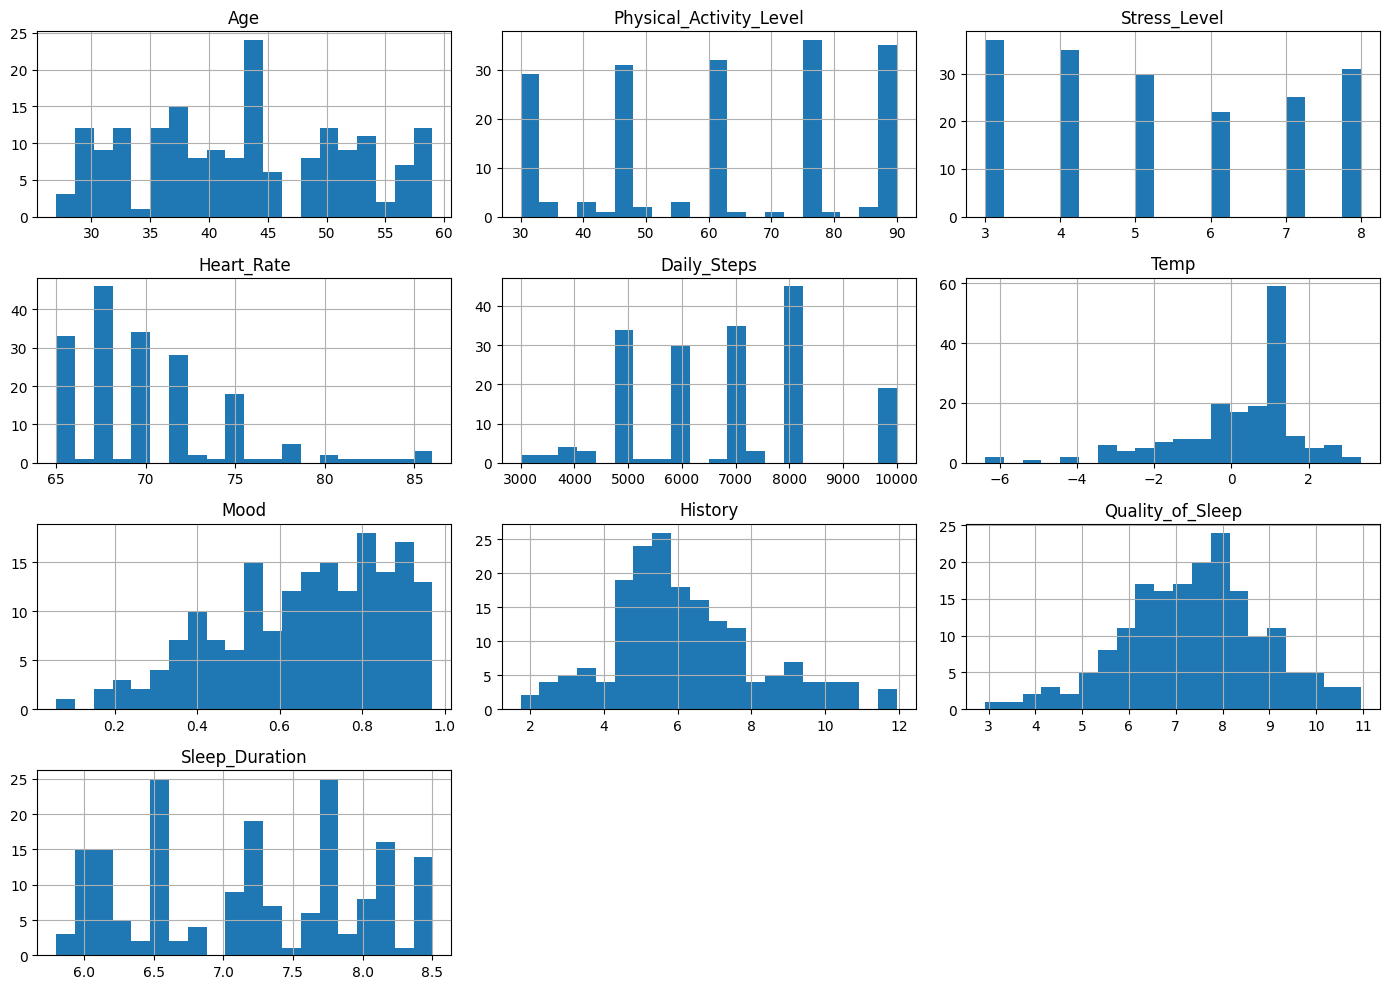

In [ ]:
num_cols = df.select_dtypes("number").columns
print(df[num_cols].skew().sort_values())

df[num_cols].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

Most of the distributions is around $0$, except for a few features such as Temp, Mood, History and Heart Rate. We can explore whether these need to be adjusted. Furthermore, we can see that many variables that features like Physical Activity Level, Heart Rate, Daily Steps and Sleep Duration have "clumps" around certain values.

In [8]:
print(df["Heart_Rate"].skew(), np.log(df["Heart_Rate"]).skew())
print(df["History"].skew(), np.log(df["History"]).skew())
print(df["Mood"].skew(), np.log(df["Mood"]).skew())
print(df["Temp"].skew(), np.log(df["Temp"]).skew())

1.2012837041380826 0.9991528363408082
0.542090237913338 -0.6362274254298736
-0.5153739919839109 -1.957826225115833
-1.29004761206933 -1.9375300756521403


c:\Users\orsik\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Most of these do not improve the skewdness values, so we keep the original features as they are.

It could also be useful to see which values correlate most with Sleep Duration.

In [5]:
print(df[num_cols].corr()["Sleep_Duration"].sort_values())

Stress_Level              -0.816001
Heart_Rate                -0.477468
Daily_Steps               -0.102529
Physical_Activity_Level    0.177873
Age                        0.350265
Temp                       0.389189
History                    0.555558
Quality_of_Sleep           0.571502
Mood                       0.634548
Sleep_Duration             1.000000
Name: Sleep_Duration, dtype: float64


The most negatively correlated variable is Stress Level, which means that with a increased Stress Level there would be a decrease in Sleep Duration. The most positively correlated value is Mood, so a better or higher Mood would imply an increase in Sleep Duration.

Let's visualise them in a graph.

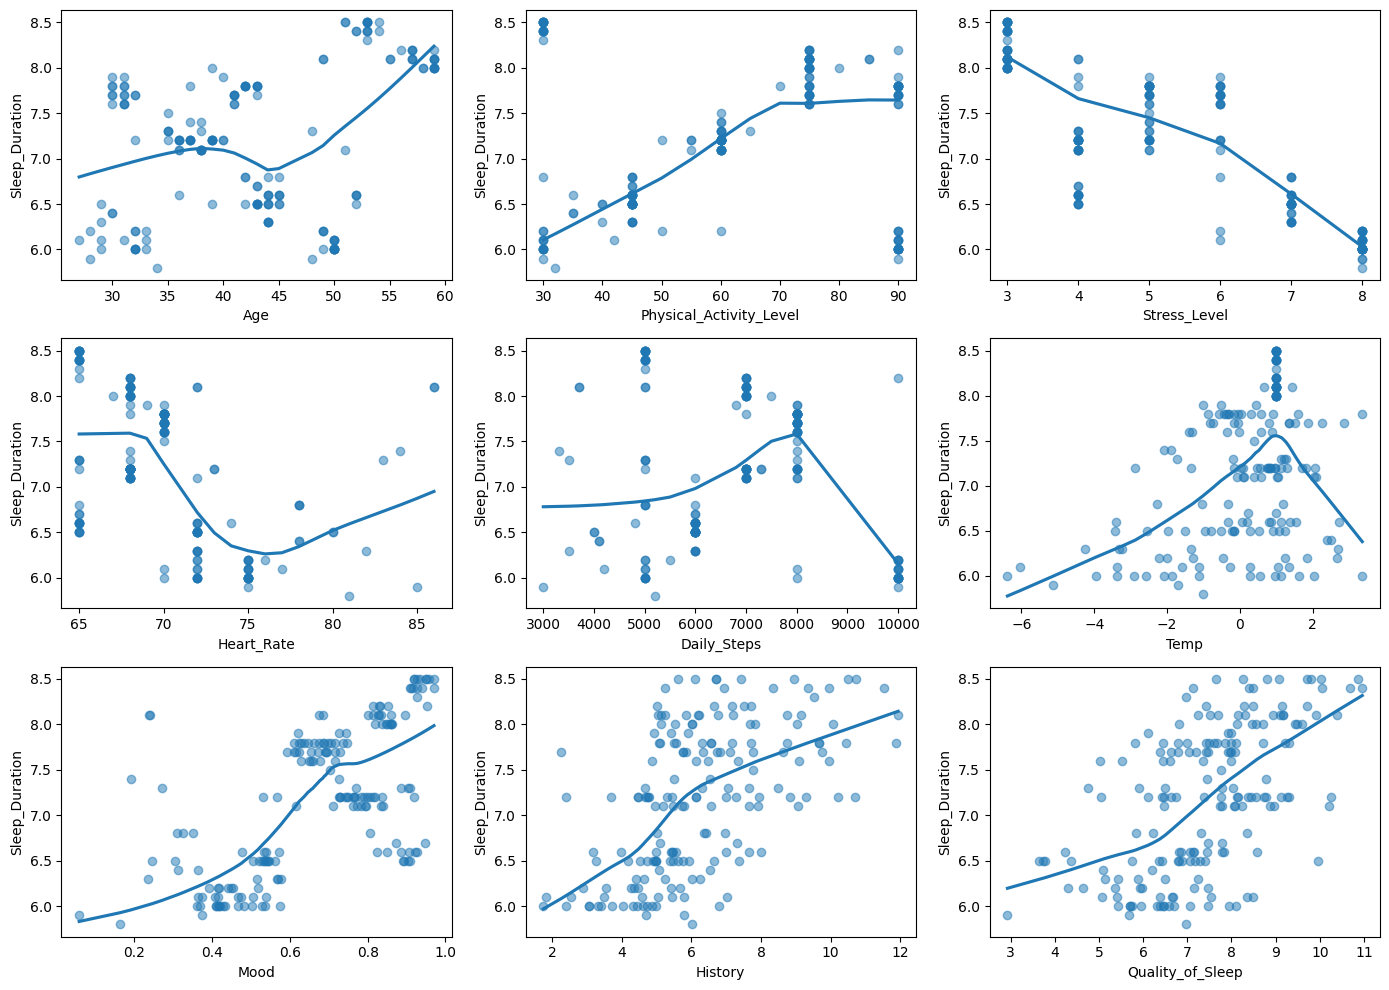

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, [c for c in num_cols if c != "Sleep_Duration"]):
    sns.regplot(data=df, x=col, y="Sleep_Duration", ax=ax, lowess=True,
                scatter_kws={"alpha": 0.5})
plt.tight_layout()
plt.show()

Some of them seem to have a almost linear relationship with Sleep Duration. We could consider an indicator for Daily Steps above $10000$. For Heart Rate maybe different bins would be a good idea. Let's continue and we can see what would suit our model later.

## Model Selection

We create a function that will clean both the train and test data sets from the things we have mentioned above.

In [10]:
def clean(d):
    d = d.copy()
    d["Sleep_Disorder"] = d["Sleep_Disorder"].fillna("None")
    d["BMI_Category"] = d["BMI_Category"].replace("Normal Weight", "Normal")
    d["Occupation"] = d["Occupation"].replace({
        "Software Engineer": "Engineer",
        "Sales Representative": "Salesperson",
        "Scientist": "Other"})
    return d

test_ids = test_df["ID"]
df = clean(df)
test_df = clean(test_df.drop(columns="ID"))

So we dummify the categorical variables and remove the response to save it separately. We also define a separate cross-validation mse function, which will be applied to every model for evaluation. We also test it for the dummified variables from the train set. If no model is given it will default to the built-in Linear Regression model.

In [11]:
X = pd.get_dummies(df.drop(columns="Sleep_Duration"), drop_first=True, dtype=float)
y = df["Sleep_Duration"]

def cv_mse(X, y, model=None, n_repeats=5):
    model = model or LinearRegression()
    cv = RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=42)
    mses = []
    for tr, va in cv.split(X):
        m = model.fit(X.iloc[tr], y.iloc[tr])
        mses.append(mean_squared_error(y.iloc[va], m.predict(X.iloc[va])))
    return np.mean(mses)

print(cv_mse(X, y))

0.11318954147731869


Based on our plots, we will try some feature engineering and test them with the Linear Regression model, to see how effective they are on their own. We try to square the Temp and Age features, create a separate bin for High Heart Rate and Daily Steps for above 10k.

In [12]:
X2 = X.copy()
X2["Steps_10k"]  = (df["Daily_Steps"] >= 10000).astype(float)
print("steps indicator:", cv_mse(X2, y))

X2 = X.copy()
X2["Temp_sq"] = df["Temp"] ** 2
print("temp squared:", cv_mse(X2, y))

X2 = X.copy()
X2["HR_high"] = (df["Heart_Rate"] >= 70).astype(float)
print("heart rate step:", cv_mse(X2, y))

X2 = X.copy()
X2["Age_sq"] = df["Age"] ** 2
print("age squared:", cv_mse(X2, y))

steps indicator: 0.08593948710662673
temp squared: 0.11450753503672584
heart rate step: 0.09955486446137703
age squared: 0.09348617918023912


We can see that it was effective on all of them except for temp squared, so we won't use that. We define a new data set and see if all three together yield the best MSE or if it gets better without one of these three.

In [13]:
X3 = X.copy()
X3["Steps_10k"] = (df["Daily_Steps"] >= 10000).astype(float)
X3["Age_sq"]    = df["Age"] ** 2
X3["HR_high"]   = (df["Heart_Rate"] >= 70).astype(float)
print("all three:", cv_mse(X3, y))

# Then drop each one in turn to see if it still earns its place
for col in ["Steps_10k", "Age_sq", "HR_high"]:
    print("without", col, ":", cv_mse(X3.drop(columns=col), y))

all three: 0.08124478015814725
without Steps_10k : 0.08845916465798848
without Age_sq : 0.08743063283172697
without HR_high : 0.079159940276646


We can see that without High Heart Rate the MSE actually improves, so we will not keep it in the train set.

In [14]:
X4 = X.copy()
X4["Steps_10k"] = (df["Daily_Steps"] >= 10000).astype(float)
X4["Age_sq"]    = df["Age"] ** 2

Next, we could see if any interaction terms would make the model better.

In [15]:
for name, feat in {
    "stress x activity": df["Stress_Level"] * df["Physical_Activity_Level"],
    "stress x age":      df["Stress_Level"] * df["Age"],
    "stress x HR":       df["Stress_Level"] * df["Heart_Rate"],
    "steps x activity":  df["Daily_Steps"] * df["Physical_Activity_Level"],
}.items():
    Xi = X4.copy()
    Xi[name] = feat
    print(name, ":", cv_mse(Xi, y))

stress x activity : 0.0729235334970446
stress x age : 0.08268799443592885
stress x HR : 0.08461872915469643
steps x activity : 0.08365305665160198


The interaction term between Stress Level and Physical Activity Level seems to lower the MSE even more, so we add it to our features.

In [16]:
X5 = X4.copy()
X5["Stress_x_Activity"] = df["Stress_Level"] * df["Physical_Activity_Level"]

We can now see how our OLS model performs and then apply Ridge and Lasso for comparison.

In [17]:
alphas = np.logspace(-3, 2, 60)
print("OLS  :", cv_mse(X5, y))
print("Ridge:", cv_mse(X5, y, make_pipeline(StandardScaler(), RidgeCV(alphas=alphas))))
print("Lasso:", cv_mse(X5, y, make_pipeline(StandardScaler(), LassoCV(alphas=alphas, max_iter=200000))))

OLS  : 0.0729235334970446
Ridge: 0.07784995411489379
Lasso: 0.07490990392261818


We can see that the basic Linear Regression is still our best model considering MSE. So, we will save those values to a csv file for now and try to improve our model further.

In [18]:
X_train = X5.copy()

X_test = pd.get_dummies(test_df, drop_first=True, dtype=float)
X_test["Steps_10k"]         = (test_df["Daily_Steps"] >= 10000).astype(float)
X_test["Age_sq"]            = test_df["Age"] ** 2
X_test["Stress_x_Activity"] = test_df["Stress_Level"] * test_df["Physical_Activity_Level"]

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

model = LinearRegression().fit(X_train, y)
preds = model.predict(X_test)

submission = pd.DataFrame({"ID": test_ids, "Sleep_Duration": preds})
submission.to_csv("submission.csv", index=False)
print(submission.head(), submission.shape)

    ID  Sleep_Duration
0    3        6.273473
1  234        6.320124
2  187        6.705730
3  220        6.185562
4  106        7.644703 (194, 2)


The next idea would be to try to use a combination of Ridge and Lasso or otehrwise called and Elastic Net. We test the Elastic Net for different ratios or Ridge and Lasso. Then we try to add more feature variables and test OLS, Ridge, Lasso and Elastic Net again, to see if it helped or not.

In [19]:
alphas = np.logspace(-4, 0, 40)
for r in [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]:
    enet = make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=r, alphas=alphas, cv=5, max_iter=200000))
    print("l1_ratio", r, ":", cv_mse(X5, y, enet))

X_big = X5.copy()
X_big["HR_high"] = (df["Heart_Rate"] >= 70).astype(float)
X_big["Temp_sq"] = df["Temp"] ** 2
X_big["Stress_x_Age"] = df["Stress_Level"] * df["Age"]
X_big["Stress_x_HR"] = df["Stress_Level"] * df["Heart_Rate"]
X_big["Steps_x_Act"] = df["Daily_Steps"] * df["Physical_Activity_Level"]
X_big["Stress_sq"] = df["Stress_Level"] ** 2
X_big["Act_sq"] = df["Physical_Activity_Level"] ** 2

print("OLS big :", cv_mse(X_big, y))
print("Ridge   :", cv_mse(X_big, y, make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 2, 60)))))
print("Lasso   :", cv_mse(X_big, y, make_pipeline(StandardScaler(), LassoCV(alphas=alphas, max_iter=200000))))
print("ENet 0.5:", cv_mse(X_big, y, make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=0.5, alphas=alphas, cv=5, max_iter=200000))))

l1_ratio 0.1 : 0.07741186598630803
l1_ratio 0.3 : 0.07676406514053392
l1_ratio 0.5 : 0.07608632674911649
l1_ratio 0.7 : 0.07637590080401765
l1_ratio 0.9 : 0.07626039459592242
l1_ratio 0.95 : 0.07633760307876386
OLS big : 0.13509295244007682
Ridge   : 0.07603082056532823
Lasso   : 0.07196730905629717
ENet 0.5: 0.07195857357544855


The MSE scores seem to improve sligthly for the Elastic Net with the added features and 0.5 ration ($50\%$ Lasso and $50\%$ Ridge), so we will save those values as well to a csv file.

In [21]:
X_test_big = pd.get_dummies(test_df, drop_first=True, dtype=float)
X_test_big["Steps_10k"] = (test_df["Daily_Steps"] >= 10000).astype(float)
X_test_big["Age_sq"] = test_df["Age"] ** 2
X_test_big["Stress_x_Activity"] = test_df["Stress_Level"] * test_df["Physical_Activity_Level"]
X_test_big["HR_high"] = (test_df["Heart_Rate"] >= 70).astype(float)
X_test_big["Temp_sq"] = test_df["Temp"] ** 2
X_test_big["Stress_x_Age"] = test_df["Stress_Level"] * test_df["Age"]
X_test_big["Stress_x_HR"] = test_df["Stress_Level"] * test_df["Heart_Rate"]
X_test_big["Steps_x_Act"] = test_df["Daily_Steps"] * test_df["Physical_Activity_Level"]
X_test_big["Stress_sq"] = test_df["Stress_Level"] ** 2
X_test_big["Act_sq"] = test_df["Physical_Activity_Level"] ** 2

X_test_big = X_test_big.reindex(columns=X_big.columns, fill_value=0)

scaler = StandardScaler().fit(X_big)
enet = ElasticNetCV(l1_ratio=0.5, alphas=np.logspace(-4, 0, 40),
                    cv=KFold(5, shuffle=True, random_state=42),
                    max_iter=200000).fit(scaler.transform(X_big), y)

print("alpha:", enet.alpha_, "| kept", (enet.coef_ != 0).sum(), "of", X_big.shape[1], "features")

preds_enet = enet.predict(scaler.transform(X_test_big))

sub = pd.DataFrame({"ID": test_ids, "Sleep_Duration": preds_enet})
sub.to_csv("submission_elnet.csv", index=False)
sub.head()

alpha: 0.011253355826007646 | kept 22 of 31 features


,ID,Sleep_Duration
0,3,6.401512
1,234,6.464600
2,187,6.850675
3,220,6.501151
4,106,7.418661


We can see that the Elastic Net kept 22 features out of the 31 we have provided.

Lastly, we can try a forward and a backward selection and see if it yields better results.

In [22]:
for direction in ["forward", "backward"]:
    for k in [8, 12, 16, 20]:
        sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select=k,
                                        direction=direction,
                                        scoring="neg_mean_squared_error", cv=5)
        print(direction, k, cv_mse(X5, y, make_pipeline(sfs, LinearRegression()), n_repeats=2))

forward 8 0.10423153112783667
forward 12 0.06634539466939092
forward 16 0.0801646742913212
forward 20 0.07789952741881756
backward 8 0.09619140225556108
backward 12 0.08377820088362546
backward 16 0.08496731536153974
backward 20 0.07273963748312917


From the above results we can see that forwards selection with $12$ features performed best regarding MSE. Just to ensure we have found the lowest MSE we check the neighbouring values around $12$ to see.

In [23]:
for k in [10, 11, 12, 13, 14]:
    sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select=k,
                                    direction="forward",
                                    scoring="neg_mean_squared_error", cv=5)
    print(k, cv_mse(X5, y, make_pipeline(sfs, LinearRegression()), n_repeats=5))

10 0.08375741544833938
11 0.07416841599797973
12 0.06798142178049468
13 0.06918495811172418
14 0.06996231689372609


It does seem like $12$ features give the ebst result, so we save this as a csv file. 

In [24]:
sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select=12,
                                direction="forward",
                                scoring="neg_mean_squared_error", cv=5)
sfs.fit(X5, y)

selected = X5.columns[sfs.get_support()]
print("Selected:", list(selected))
print("Dropped :", list(X5.columns[~sfs.get_support()]))

model = LinearRegression().fit(X5[selected], y)
preds_fwd = model.predict(X_test[selected])

sub = pd.DataFrame({"ID": test_ids, "Sleep_Duration": preds_fwd})
sub.to_csv("submission_forward12.csv", index=False)
sub.head()

Selected: ['Age', 'Stress_Level', 'History', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Lawyer', 'Occupation_Salesperson', 'Occupation_Teacher', 'BMI_Category_Overweight', 'Steps_10k', 'Age_sq', 'Stress_x_Activity']
Dropped : ['Physical_Activity_Level', 'Heart_Rate', 'Daily_Steps', 'Temp', 'Mood', 'Quality_of_Sleep', 'Gender_Male', 'Occupation_Nurse', 'Occupation_Other', 'BMI_Category_Obese', 'Sleep_Disorder_None', 'Sleep_Disorder_Sleep Apnea']


,ID,Sleep_Duration
0,3,6.347951
1,234,6.385680
2,187,6.777912
3,220,6.409069
4,106,7.517074


Here, we can also see the features that were selected and the one taht were dropped during foreward selection. 

After submission to the Kaggle competition the models had the following results:
 - OLS model ~ 0.02977,
 - Elastic Net model ~ 0.04269,
 - Forward Selection model ~ 0.3808.